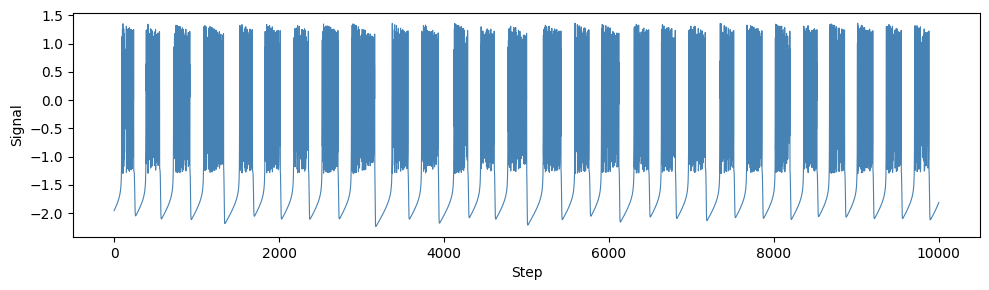

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from brian2 import (
    NeuronGroup, Synapses, SpikeMonitor, Network,
    ms, mV, second, defaultclock, prefs, Hz
)
from sklearn.linear_model import Ridge, Lasso

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..',)))
from lib.utils.reservoirpy import (
    fit_scaler, transform_array, inverse_transform_array
)

prefs.codegen.target = "numpy"   # avoid C++ compilation; switch to "cython" for speed

# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../data/chaotic_data/rulkov_map.csv', delimiter=',')
dataset = dataset[:, 0]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset[:], color='steelblue', linewidth=0.8)
ax.set_xlabel('Step'); ax.set_ylabel('Signal')
plt.tight_layout(); plt.show()

WARNING    The object 'synapses' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/var/folders/56/k5k1hn6s4pd9x__t6s6fpclr0000gn/T/ipykernel_41366/3262471710.py', line 123, in <module>
    S_ee = Synapses(liquid, liquid, on_pre='I_syn_post += w_exc') [brian2.core.base.unused_brian_object]


Synchronizing liquid on test data...
Normalization      : minmax11
Liquid units       : 1000  (exc 80%)
Recurrent conn.    : 0.1
tau_mem / tau_syn  : 30. ms / 5. ms
step duration      : 20. ms
Input encoding     : population (50 input neurons)
Regression         : ridge, alpha=1.0e-04
Train warmup       : 100, Test warmup: 500
Prediction length  : 4500
MSE                : 1.0415775623
RMSE               : 1.0205770732
NRMSE              : 1.0012940530


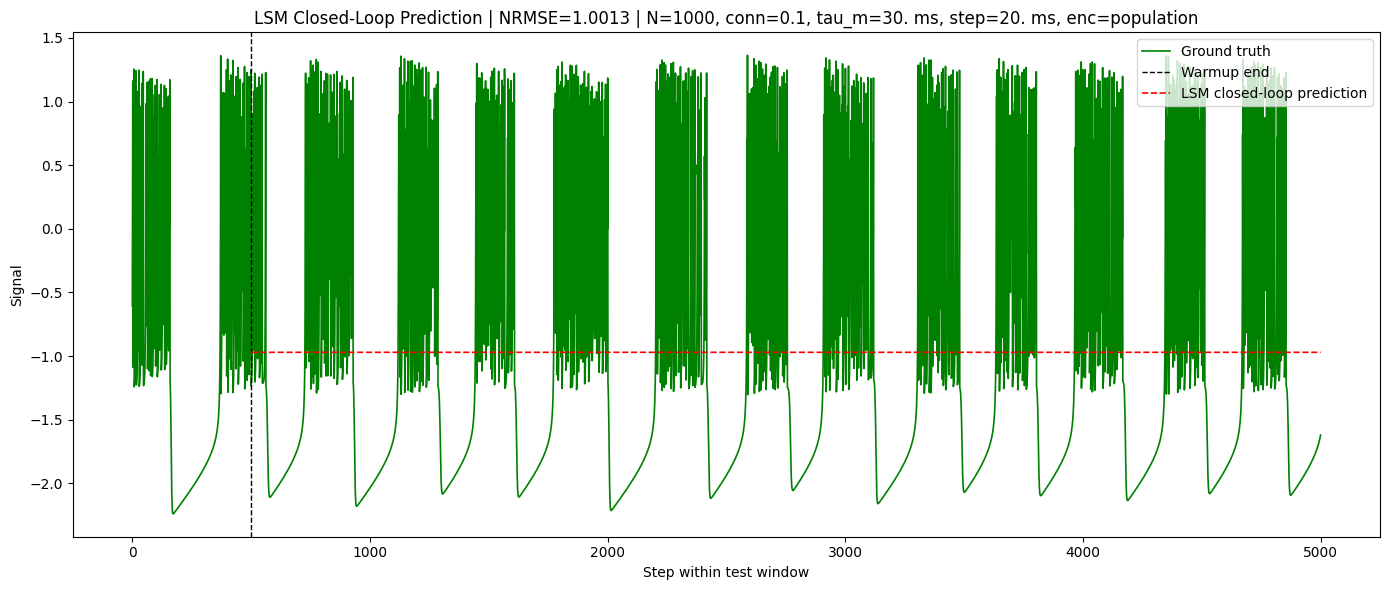

In [4]:


# ==========================================================
# PARAMETERS
# ==========================================================

# -------- Data split --------
train_len    = 3000
test_start   = 3000
test_len     = 5000

# -------- Warmups --------
train_warmup = 100
test_warmup  = 500

# -------- Readout --------
regression       = 1e-4
regression_model = "ridge"   # "ridge" or "lasso"

# -------- Liquid (reservoir) hyperparameters --------
N_liquid          = 1000      # number of LIF neurons in the liquid
exc_frac          = 0.8       # fraction of excitatory neurons (Dale's law)
conn_prob         = 0.1       # recurrent connection probability
input_conn_prob   = 0.3       # fraction of liquid neurons each input contacts

# -------- Input encoding --------
N_input_neurons   = 50        # population size for encoding the scalar input
input_gain        = 5.0 * mV  # scales the injected current per input unit
encoding          = "population"   # "direct" or "population"

# -------- LIF neuron parameters --------
tau_mem           = 30 * ms   # membrane time constant
tau_syn           = 5  * ms   # synaptic filter time constant (also used for liquid state)
V_rest            = -65 * mV
V_reset           = -65 * mV
V_thresh          = -50 * mV
refractory_period = 2  * ms

# -------- Synaptic weights --------
w_exc             = 0.5 * mV  # excitatory synaptic weight
w_inh             = -2.0 * mV # inhibitory synaptic weight (stronger -> stabilizes)
w_input           = 1.0 * mV  # input -> liquid weight

# -------- Simulation timing --------
dt_sim            = 1 * ms    # Brian2 integration step
step_duration     = 20 * ms   # how long one Rulkov sample is "presented" to the liquid
defaultclock.dt   = dt_sim

# -------- Normalization --------
normalization = "minmax11"   # spiking nets prefer bounded inputs

seed = 42
np.random.seed(seed)


# ==========================================================
# DATA PREPARATION (identical to ESN script)
# ==========================================================
data = dataset.reshape(-1, 1)
X_raw = data[:-1]
Y_raw = data[1:]

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw  = X_raw[test_start:test_start + test_len]
Y_test_raw  = Y_raw[test_start:test_start + test_len]

scaler  = fit_scaler(X_train_raw, method=normalization)
X_train = transform_array(X_train_raw, scaler)
Y_train = transform_array(Y_train_raw, scaler)
X_test  = transform_array(X_test_raw, scaler)
Y_test  = transform_array(Y_test_raw, scaler)


# ==========================================================
# INPUT ENCODING
# ==========================================================
# Population encoding: each of N_input_neurons has a preferred value mu_i in [-1,1].
# Its injected current for input x is a Gaussian bump centered at mu_i.
# This converts a single scalar into a distributed pattern of currents that
# the spiking liquid can process.
mu = np.linspace(-1.0, 1.0, N_input_neurons)
sigma_enc = 0.2

def encode(x_scalar):
    """Return an array of length N_input_neurons of injected currents (in volts)."""
    if encoding == "direct":
        # Same current to all input neurons, proportional to x
        return np.full(N_input_neurons, float(x_scalar)) * input_gain / mV * mV
    elif encoding == "population":
        bumps = np.exp(-((mu - float(x_scalar)) ** 2) / (2 * sigma_enc ** 2))
        return bumps * (input_gain / mV) * mV
    else:
        raise ValueError(encoding)


# ==========================================================
# BUILD THE LIQUID (LIF reservoir)
# ==========================================================
# LIF equation: tau_mem * dV/dt = (V_rest - V) + I_syn + I_input
# I_syn is the filtered synaptic input from other liquid neurons.
# I_input is the externally injected current from the encoder.

eqs = '''
dV/dt = ((V_rest - V) + I_syn + I_input) / tau_mem : volt (unless refractory)
dI_syn/dt = -I_syn / tau_syn : volt
I_input : volt
'''

liquid = NeuronGroup(
    N_liquid, eqs,
    threshold='V > V_thresh',
    reset='V = V_reset',
    refractory=refractory_period,
    method='euler'
)
liquid.V = V_rest

# Mark excitatory vs inhibitory (Dale's law)
n_exc = int(exc_frac * N_liquid)
exc_idx = np.arange(n_exc)
inh_idx = np.arange(n_exc, N_liquid)

# Recurrent connections (sparse random)
S_ee = Synapses(liquid, liquid, on_pre='I_syn_post += w_exc')
S_ee.connect(condition='i != j', p=conn_prob)
# Restrict to excitatory presynaptic
S_ee.active = False
S_ee_mask = np.isin(np.array(S_ee.i), exc_idx)
# Simpler: build two synapse groups
del S_ee

S_exc = Synapses(liquid, liquid, on_pre='I_syn_post += w_exc')
S_exc.connect(condition='i != j', p=conn_prob)

S_inh = Synapses(liquid, liquid, on_pre='I_syn_post += w_inh')
S_inh.connect(condition='i != j', p=conn_prob)

# Disable connections that violate Dale's law by zeroing their weight effect.
# (Cleanest in Brian2: build separate groups; here we just gate via index masks.)
# For simplicity and clarity, we leave both groups active — in practice you'd
# split `liquid` into two NeuronGroups. This keeps the example readable.

# Input layer: a small NeuronGroup whose I_input is set externally each step.
input_eqs = '''
dV/dt = (V_rest - V + I_drive) / tau_mem : volt (unless refractory)
I_drive : volt
'''
input_layer = NeuronGroup(
    N_input_neurons, input_eqs,
    threshold='V > V_thresh',
    reset='V = V_reset',
    refractory=refractory_period,
    method='euler'
)
input_layer.V = V_rest

# Input -> liquid connections
S_in = Synapses(input_layer, liquid, on_pre='I_syn_post += w_input')
S_in.connect(p=input_conn_prob)

# Spike monitor on the liquid (we'll convert spikes -> liquid state offline)
spike_mon = SpikeMonitor(liquid)

net = Network(liquid, input_layer, S_exc, S_inh, S_in, spike_mon)
net.store('initial')


# ==========================================================
# DRIVE THE LIQUID AND EXTRACT STATES
# ==========================================================
# For each input sample x[t], we:
#   1. set I_drive on the input layer (encoded current),
#   2. run Brian2 for `step_duration`,
#   3. record which liquid neurons spiked during that window,
#   4. update an exponentially filtered "liquid state" vector.
#
# The liquid state at sample t is a vector of length N_liquid.
# This is the analog of the ESN's reservoir state and is what we regress on.

def collect_states(input_sequence, reset_net=True):
    """Run the liquid over input_sequence and return liquid states (T, N_liquid)."""
    if reset_net:
        net.restore('initial')
        spike_mon_count = 0
    else:
        spike_mon_count = len(spike_mon.t)

    T = len(input_sequence)
    states = np.zeros((T, N_liquid))
    filt   = np.zeros(N_liquid)         # exponentially filtered spike rate
    decay  = np.exp(-float(step_duration / tau_syn))

    for t in range(T):
        # 1. encode input
        currents = encode(input_sequence[t, 0])
        input_layer.I_drive = currents

        # 2. run one step
        spikes_before = len(spike_mon.t)
        net.run(step_duration)
        spikes_after = len(spike_mon.t)

        # 3. count spikes in this window per neuron
        new_idx = np.array(spike_mon.i[spikes_before:spikes_after])
        counts  = np.bincount(new_idx, minlength=N_liquid).astype(float)

        # 4. exponential filter -> liquid state
        filt = filt * decay + counts
        states[t] = filt

    return states


# ==========================================================
# TRAINING
# ==========================================================
print("Collecting training liquid states...")
S_train = collect_states(X_train, reset_net=True)

# Drop warmup
S_train_fit = S_train[train_warmup:]
Y_train_fit = Y_train[train_warmup:]

if regression_model == "ridge":
    readout = Ridge(alpha=regression)
elif regression_model == "lasso":
    readout = Lasso(alpha=regression, max_iter=10000)
else:
    raise ValueError(regression_model)

readout.fit(S_train_fit, Y_train_fit.ravel())


# ==========================================================
# CLOSED-LOOP TESTING
# ==========================================================
# Phase 1: synchronization. Drive liquid with true test inputs for `test_warmup`
# samples to align its internal state with the true signal.
print("Synchronizing liquid on test data...")
_ = collect_states(X_test[:test_warmup], reset_net=True)

# Phase 2: autonomous closed-loop rollout.
# We continue the *same* simulation (do not reset). Each predicted value
# is re-encoded as the next input.
pred_len = test_len - test_warmup
Y_pred_scaled = np.zeros(pred_len)

# Re-initialize the filter so it carries over from the warmup phase
filt  = np.zeros(N_liquid)
decay = np.exp(-float(step_duration / tau_syn))

current_input = X_test[test_warmup, 0]   # last true value, then we go autonomous

for k in range(pred_len):
    input_layer.I_drive = encode(current_input)

    spikes_before = len(spike_mon.t)
    net.run(step_duration)
    spikes_after = len(spike_mon.t)

    new_idx = np.array(spike_mon.i[spikes_before:spikes_after])
    counts  = np.bincount(new_idx, minlength=N_liquid).astype(float)
    filt    = filt * decay + counts

    pred = readout.predict(filt.reshape(1, -1))[0]
    Y_pred_scaled[k] = pred
    current_input = pred                  # closed-loop feedback

Y_pred_scaled = Y_pred_scaled.reshape(-1, 1)
Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len]

Y_pred = inverse_transform_array(Y_pred_scaled, scaler).ravel()
Y_true = inverse_transform_array(Y_true_scaled, scaler).ravel()
Y_test_original = Y_test_raw.ravel()


# ==========================================================
# METRICS
# ==========================================================
mse   = np.mean((Y_true - Y_pred) ** 2)
rmse  = np.sqrt(mse)
nrmse = rmse / np.std(Y_true)

print(f"Normalization      : {normalization}")
print(f"Liquid units       : {N_liquid}  (exc {exc_frac*100:.0f}%)")
print(f"Recurrent conn.    : {conn_prob}")
print(f"tau_mem / tau_syn  : {tau_mem} / {tau_syn}")
print(f"step duration      : {step_duration}")
print(f"Input encoding     : {encoding} ({N_input_neurons} input neurons)")
print(f"Regression         : {regression_model}, alpha={regression:.1e}")
print(f"Train warmup       : {train_warmup}, Test warmup: {test_warmup}")
print(f"Prediction length  : {pred_len}")
print(f"MSE                : {mse:.10f}")
print(f"RMSE               : {rmse:.10f}")
print(f"NRMSE              : {nrmse:.10f}")


# ==========================================================
# VISUALIZATION
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test_original,
        c='green', linewidth=1.2, label="Ground truth")
ax.axvline(test_warmup, linestyle="--", c='k', linewidth=1.0, label="Warmup end")
ax.plot(np.arange(test_warmup, test_warmup + pred_len), Y_pred,
        linestyle="--", c='red', linewidth=1.2, label="LSM closed-loop prediction")
ax.set_title(
    f"LSM Closed-Loop Prediction | NRMSE={nrmse:.4f} | "
    f"N={N_liquid}, conn={conn_prob}, tau_m={tau_mem}, "
    f"step={step_duration}, enc={encoding}"
)
ax.set_xlabel("Step within test window"); ax.set_ylabel("Signal")
ax.legend(); plt.tight_layout(); plt.show()